# 302 — Probability-weighted parameter uncertainty cost for depletion_q designs

This notebook holds the validated baseline `depletion_q` Pareto designs fixed and re-evaluates those same pumping designs across a probability distribution of transmissivity values.

Current implemented parameter: **transmissivity**.

Main question:

> If transmissivity is uncertain, what is the expected streamflow error or shortfall for each pumping design on the baseline depletion_q Pareto front?


## 1. Imports, helper reload, and user controls

Start with a small test run using `N_TEST_MEMBERS = 10`. For the full run, set `N_TEST_MEMBERS = None` and `RERUN_REEVALUATION = True`.

After the full run finishes, you can set `RERUN_REEVALUATION = False` to load the cached re-evaluations.


In [1]:
from pathlib import Path
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.modules.pop("uncertainty_project_helpers_depletion_q", None)
importlib.invalidate_caches()
import uncertainty_project_helpers_depletion_q as up

print("Helper imported from:", up.__file__)
print("Helper version:", up.HELPER_VERSION)

PROJECT_DIR = up.find_lpr_pycap_opt_dir()
NOTEBOOK_DIR = PROJECT_DIR / "notebooks" / "Uncertainty_Project_depletion_q"
CACHE_DIR = NOTEBOOK_DIR / "cached_reevaluations"

RUN_NAME = "depletion_q_baseline_0.0_1.0_0.01"
PARAMETER_TO_RUN = "transmissivity"
PARAMETER_OUTPUT_TAG = PARAMETER_TO_RUN.lower().replace(" ", "_")

PARAMETER_SIGMA_FRACTION = 0.10
N_SIGMA_EACH_SIDE = 2.0
N_PARAMETER_VALUES = 11

RERUN_REEVALUATION = False
N_TEST_MEMBERS = None

OUTPUT_DIR = NOTEBOOK_DIR / "project_output" / "302_probability_weighted_parameter_uncertainty_depletion_q" / PARAMETER_OUTPUT_TAG
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_FILE = CACHE_DIR / f"302_depletion_q_{PARAMETER_OUTPUT_TAG}_probability_reevaluation.csv"
ERROR_CACHE_FILE = CACHE_DIR / f"302_depletion_q_{PARAMETER_OUTPUT_TAG}_probability_reevaluation_errors.csv"

up.apply_plot_style()

print("PROJECT_DIR:", PROJECT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CACHE_FILE:", CACHE_FILE)
print("PARAMETER_TO_RUN:", PARAMETER_TO_RUN)
print("PARAMETER_SIGMA_FRACTION:", PARAMETER_SIGMA_FRACTION)
print("N_SIGMA_EACH_SIDE:", N_SIGMA_EACH_SIDE)
print("N_PARAMETER_VALUES:", N_PARAMETER_VALUES)
print("RERUN_REEVALUATION:", RERUN_REEVALUATION)
print("N_TEST_MEMBERS:", N_TEST_MEMBERS)


Helper imported from: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/uncertainty_project_helpers_depletion_q.py
Helper version: 2026-05-23_depletion_q_304_v2_clean_member_labels_and_reliability_plot
PROJECT_DIR: /workspaces/LPR_redux/LPR_pycap_opt
OUTPUT_DIR: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302_probability_weighted_parameter_uncertainty_depletion_q/transmissivity
CACHE_FILE: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/cached_reevaluations/302_depletion_q_transmissivity_probability_reevaluation.csv
PARAMETER_TO_RUN: transmissivity
PARAMETER_SIGMA_FRACTION: 0.1
N_SIGMA_EACH_SIDE: 2.0
N_PARAMETER_VALUES: 11
RERUN_REEVALUATION: False
N_TEST_MEMBERS: None


## 2. Load the depletion_q baseline context and Pareto designs

The baseline Pareto designs come from the `depletion_q` MOU archive. The pumping objective is `obj_well`, which represents decision-variable pumping only, not all fixed/background pumping in the model.


In [2]:
context = up.load_depletion_q_context(RUN_NAME, project_dir=PROJECT_DIR)
archive = up.read_pareto_archive_summary(RUN_NAME, context.run_dir)
pareto_final = up.select_final_feasible_front1(archive)
dv_df = up.load_decision_variable_population(context.run_dir)

if N_TEST_MEMBERS is not None:
    pareto_final = pareto_final.head(int(N_TEST_MEMBERS)).copy()

all_q_cols = up.get_q_columns(dv_df)

print("Run directory:", context.run_dir)
print("Base T:", context.base_T)
print("Number of final front members selected:", len(pareto_final))
print("Decision-variable population shape:", dv_df.shape)
print("Number of all pumping columns in dv_df:", len(all_q_cols))
print("Number of decision-variable pumping columns from PEST control file:", len(context.decvar_q_cols))

display(pareto_final[["member", "generation", "obj_well", up.DEPLETION_OBS_NAME]].head())
display(dv_df.head())


Run directory: /workspaces/LPR_redux/LPR_pycap_opt/pycap_runs/pycap_pest/run_depletion_q_baseline_0.0_1.0_0.01
Base T: 1700.0
Number of final front members selected: 296
Decision-variable population shape: (8772, 327)
Number of all pumping columns in dv_df: 327
Number of decision-variable pumping columns from PEST control file: 86


,member,generation,obj_well,lpr:total_combined:bdpl
8495,152,50,17542.80,4.782580
8496,gen=36_member=6021_pso,50,7060.34,0.811083
8497,16,50,17265.50,4.489270
8498,130,50,17325.00,4.690710
8499,95,50,17459.90,4.701270


,well_1013__q,well_1302__q,well_1323__q,well_1486__q,well_1584__q,well_1589__q,well_1643__q,well_1683__q,well_1860__q,well_23610__q,...,well_93143__q,well_93349__q,well_93422__q,well_93423__q,well_93424__q,well_93469__q,well_93832__q,well_94302__q,well_94988__q,well_95068__q
68,125.1,88.2,76.2,195.670613,137.952010,264.1,114.5,260.6,195.7,231.977419,...,0.578136,27.2,0.1,0.1,0.2,163.452296,14.6,143.870904,11.1,40.3
152,125.1,88.2,76.2,263.694528,134.751495,264.1,114.5,260.6,195.7,212.789243,...,0.643249,27.2,0.1,0.1,0.2,188.927899,14.6,171.709627,11.1,40.3
16,125.1,88.2,76.2,200.682701,170.213382,264.1,114.5,260.6,195.7,190.889313,...,0.702573,27.2,0.1,0.1,0.2,145.038900,14.6,153.466090,11.1,40.3
130,125.1,88.2,76.2,265.956362,144.227698,264.1,114.5,260.6,195.7,218.143802,...,0.635653,27.2,0.1,0.1,0.2,171.823604,14.6,133.683458,11.1,40.3
95,125.1,88.2,76.2,208.937516,136.708745,264.1,114.5,260.6,195.7,204.507103,...,0.694806,27.2,0.1,0.1,0.2,182.539445,14.6,153.717470,11.1,40.3


## 3. Build the transmissivity probability model

The probability model is a discrete normal distribution centered on the baseline transmissivity value. With the current settings, one standard deviation is 10% of baseline T and the sampled range is ±2σ, or 0.8T to 1.2T.


In [3]:
if PARAMETER_TO_RUN != "transmissivity":
    raise NotImplementedError("302 currently implements transmissivity only. Storage and streambed conductance will be added after we confirm their PyCap input names.")

probability_table = up.make_normal_parameter_probability_table(
    parameter_name=PARAMETER_TO_RUN,
    base_value=context.base_T,
    sigma_fraction=PARAMETER_SIGMA_FRACTION,
    n_sigma_each_side=N_SIGMA_EACH_SIDE,
    n_values=N_PARAMETER_VALUES,
)

probability_table.to_csv(OUTPUT_DIR / f"302_{PARAMETER_OUTPUT_TAG}_probability_weights.csv", index=False)

print("Probability weights sum:", probability_table["probability_weight"].sum())
print("Minimum factor:", probability_table["parameter_factor"].min())
print("Maximum factor:", probability_table["parameter_factor"].max())
display(probability_table)


Probability weights sum: 1.0
Minimum factor: 0.8
Maximum factor: 1.2


,parameter_name,scenario,z_score,parameter_factor,parameter_value,probability_weight
0,transmissivity,T_zminus_2p00,-2.0,0.80,1360.0,0.022191
1,transmissivity,T_zminus_1p60,-1.6,0.84,1428.0,0.045589
2,transmissivity,T_zminus_1p20,-1.2,0.88,1496.0,0.079811
3,transmissivity,T_zminus_0p80,-0.8,0.92,1564.0,0.119065
4,transmissivity,T_zminus_0p40,-0.4,0.96,1632.0,0.151361
5,transmissivity,baseline_T,0.0,1.00,1700.0,0.163967
6,transmissivity,T_zplus_0p40,0.4,1.04,1768.0,0.151361
7,transmissivity,T_zplus_0p80,0.8,1.08,1836.0,0.119065
8,transmissivity,T_zplus_1p20,1.2,1.12,1904.0,0.079811
9,transmissivity,T_zplus_1p60,1.6,1.16,1972.0,0.045589


## 4. Re-evaluate the fixed baseline designs across the probability model

This is the expensive step. The number of PyCap calls is:

`number of Pareto designs × number of parameter values`

For the full run, this will be approximately `296 × 11 = 3,256` re-evaluations.


In [4]:
scenarios = up.probability_table_to_T_scenarios(probability_table)
expected_rows = len(pareto_final) * len(scenarios)
print("Number of scenarios:", len(scenarios))
print("Expected rows:", expected_rows)

if RERUN_REEVALUATION or not CACHE_FILE.exists():
    results_long_raw, error_df = up.reevaluate_depletion_q_designs(
        pareto_final=pareto_final,
        dv_df=dv_df,
        q_cols=all_q_cols,
        context=context,
        scenarios=scenarios,
        progress_every=100,
    )
    results_long_raw.to_csv(CACHE_FILE, index=False)
    up.write_error_cache(error_df, ERROR_CACHE_FILE)
else:
    results_long_raw = pd.read_csv(CACHE_FILE)
    error_df = up.read_csv_if_not_empty(ERROR_CACHE_FILE)

if len(results_long_raw) != expected_rows:
    raise ValueError(f"Cached or generated result has {len(results_long_raw)} rows, but {expected_rows} rows were expected. Set RERUN_REEVALUATION = True to rebuild the cache for the current N_TEST_MEMBERS setting.")

results_long = up.add_probability_table_metadata(results_long_raw, probability_table)

print("Re-evaluation rows:", len(results_long))
print("Error rows:", len(error_df))
if not error_df.empty:
    display(error_df.head())

display(results_long.head())


Number of scenarios: 11
Expected rows: 3256
Scenario: T_zminus_2p00 | T factor: 0.8 | T value: 1360
  Re-evaluating 1 of 3256: scenario=T_zminus_2p00, member=152


KeyboardInterrupt: 

## 5. Calculate probability-weighted uncertainty metrics

For each pumping design, this section calculates expected streamflow, uncertainty bands, streamflow error, streamflow shortfall, and standard deviation across the transmissivity probability model.


In [ ]:
member_summary = up.summarize_probability_weighted_depletion_q(results_long)
overall_summary = up.summarize_probability_weighted_overall(member_summary)

long_path = OUTPUT_DIR / f"302_{PARAMETER_OUTPUT_TAG}_probability_reevaluation_long.csv"
member_path = OUTPUT_DIR / f"302_{PARAMETER_OUTPUT_TAG}_probability_weighted_member_summary.csv"
overall_path = OUTPUT_DIR / f"302_{PARAMETER_OUTPUT_TAG}_probability_weighted_overall_summary.csv"

results_long.to_csv(long_path, index=False)
member_summary.to_csv(member_path, index=False)
overall_summary.to_csv(overall_path, index=False)

print("Saved long table:", long_path)
print("Saved member summary:", member_path)
print("Saved overall summary:", overall_path)

display(member_summary.head())
display(overall_summary)


Saved long table: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302_probability_weighted_parameter_uncertainty_depletion_q/transmissivity/302_transmissivity_probability_reevaluation_long.csv
Saved member summary: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302_probability_weighted_parameter_uncertainty_depletion_q/transmissivity/302_transmissivity_probability_weighted_member_summary.csv
Saved overall summary: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302_probability_weighted_parameter_uncertainty_depletion_q/transmissivity/302_transmissivity_probability_weighted_overall_summary.csv


,member,pumping_objective_reeval_cfs,baseline_streamflow_cfs,baseline_depletion_cfs,expected_streamflow_cfs,expected_depletion_cfs,expected_streamflow_bias_from_baseline_cfs,expected_depletion_bias_from_baseline_cfs,probability_weighted_absolute_streamflow_error_cfs,probability_weighted_absolute_depletion_error_cfs,probability_weighted_streamflow_shortfall_cfs,probability_weighted_depletion_excess_cfs,streamflow_std_cfs,depletion_std_cfs,streamflow_p05_cfs,streamflow_p50_cfs,streamflow_p95_cfs,depletion_p05_cfs,depletion_p50_cfs,depletion_p95_cfs
0,152,39.085441,3.817418,4.782582,3.825280,4.774720,0.007863,-0.007863,0.180805,0.180805,0.086471,0.086471,0.225241,0.225241,3.414862,3.769368,4.167450,4.321947,4.732900,5.097670
1,gen=36_member=6021_pso,15.730429,7.788917,0.811083,7.790116,0.809884,0.001199,-0.001199,0.053741,0.053741,0.026271,0.026271,0.066850,0.066850,7.665405,7.774467,7.890374,0.678666,0.796406,0.907192
2,16,38.467529,4.110726,4.489274,4.118108,4.481892,0.007382,-0.007382,0.174415,0.174415,0.083517,0.083517,0.217262,0.217262,3.721681,4.064366,4.447912,4.045777,4.441348,4.793701
3,130,38.600146,3.909289,4.690711,3.916913,4.683087,0.007623,-0.007623,0.178071,0.178071,0.085224,0.085224,0.221806,0.221806,3.512500,3.861904,4.253716,4.237521,4.641758,5.001312
4,95,38.900681,3.898732,4.701268,3.906329,4.693671,0.007598,-0.007598,0.180247,0.180247,0.086325,0.086325,0.224513,0.224513,3.496811,3.850697,4.247152,4.242826,4.651791,5.015889


,metric,value
0,n_members,296.000000
1,mean_probability_weighted_absolute_streamflow_error_cfs,0.126483
2,max_probability_weighted_absolute_streamflow_error_cfs,0.180805
3,mean_probability_weighted_streamflow_shortfall_cfs,0.061058
4,max_probability_weighted_streamflow_shortfall_cfs,0.086471
5,mean_streamflow_std_cfs,0.157468
6,max_streamflow_std_cfs,0.225241
7,mean_expected_streamflow_bias_from_baseline_cfs,0.004368
8,mean_probability_weighted_absolute_depletion_error_cfs,0.126483
9,mean_probability_weighted_depletion_excess_cfs,0.061058


## 6. Create probability-weighted uncertainty figures

The figures focus on streamflow versus pumping because the final management question is about how pumping plans affect Little Plover streamflow under parameter uncertainty. Depletion is retained in the tables as the direct PyCap response metric.


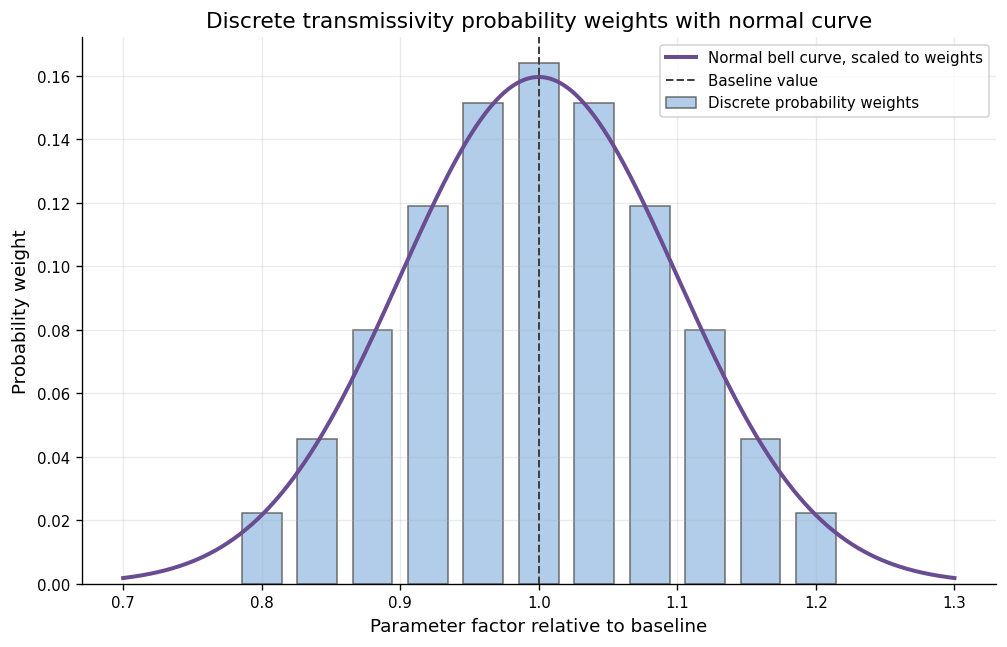

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302_probability_weighted_parameter_uncertainty_depletion_q/transmissivity/302_transmissivity_probability_weights_with_bell_curve.png


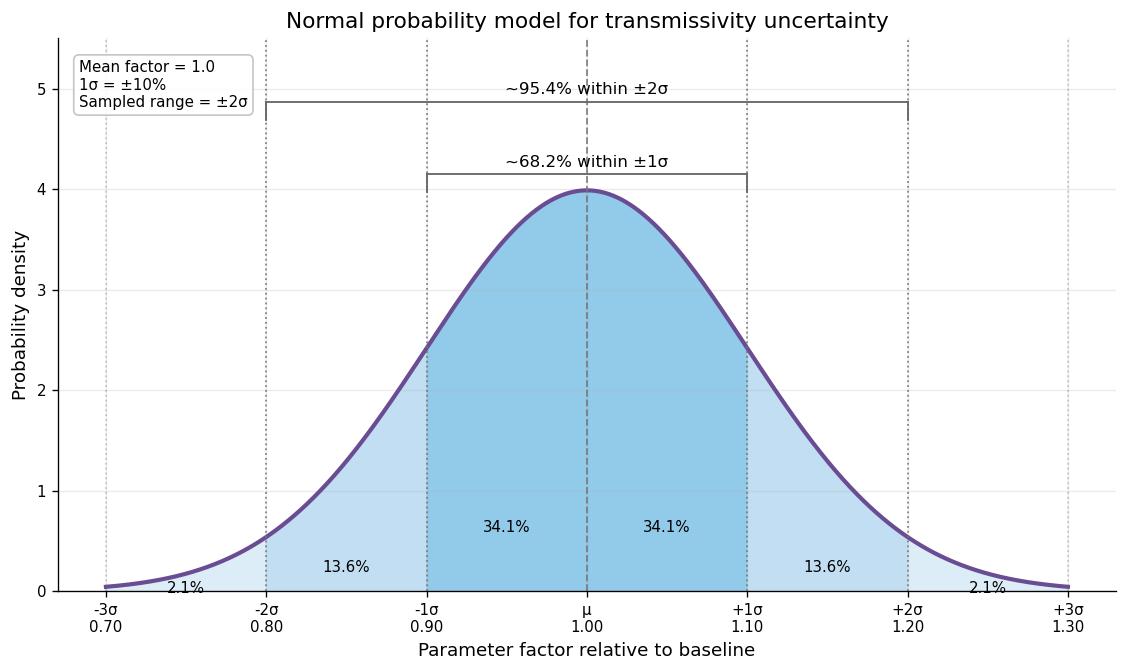

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302_probability_weighted_parameter_uncertainty_depletion_q/transmissivity/302_transmissivity_probability_shaded_sigma_regions.png


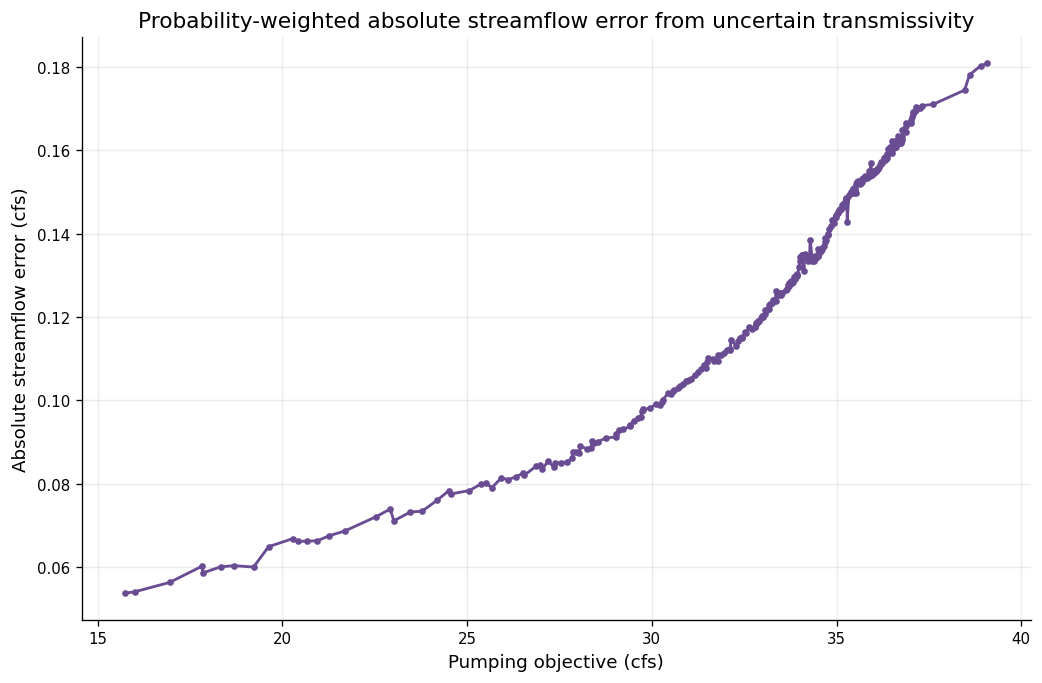

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302_probability_weighted_parameter_uncertainty_depletion_q/transmissivity/302_transmissivity_probability_weighted_absolute_streamflow_error.png


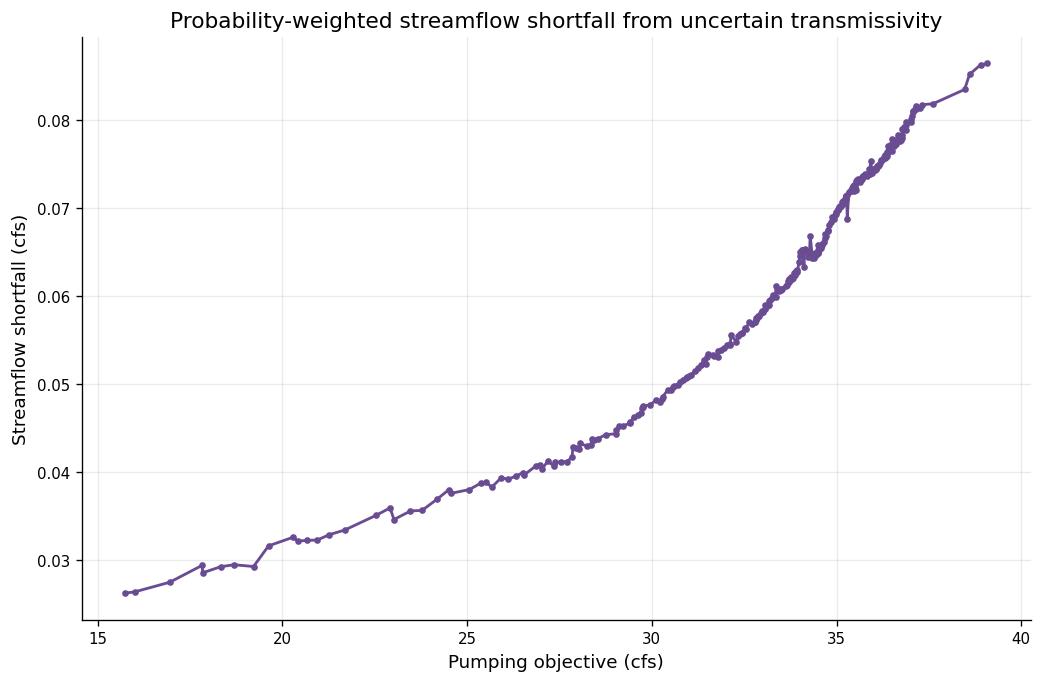

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302_probability_weighted_parameter_uncertainty_depletion_q/transmissivity/302_transmissivity_probability_weighted_streamflow_shortfall.png


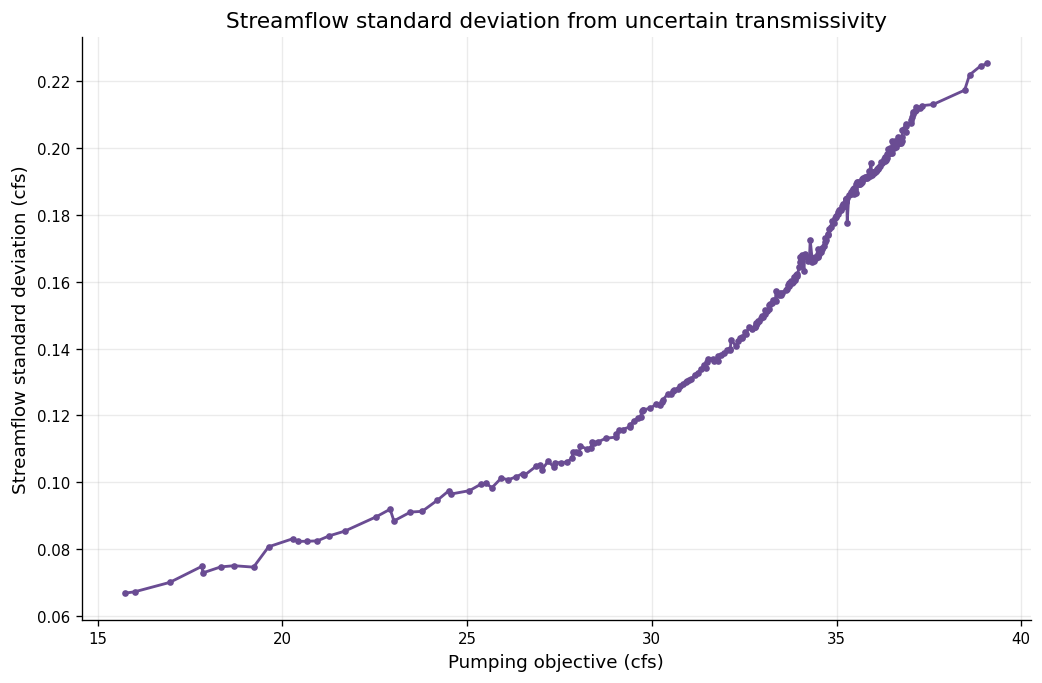

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302_probability_weighted_parameter_uncertainty_depletion_q/transmissivity/302_transmissivity_streamflow_standard_deviation.png


/workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/uncertainty_project_helpers_depletion_q.py:645: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


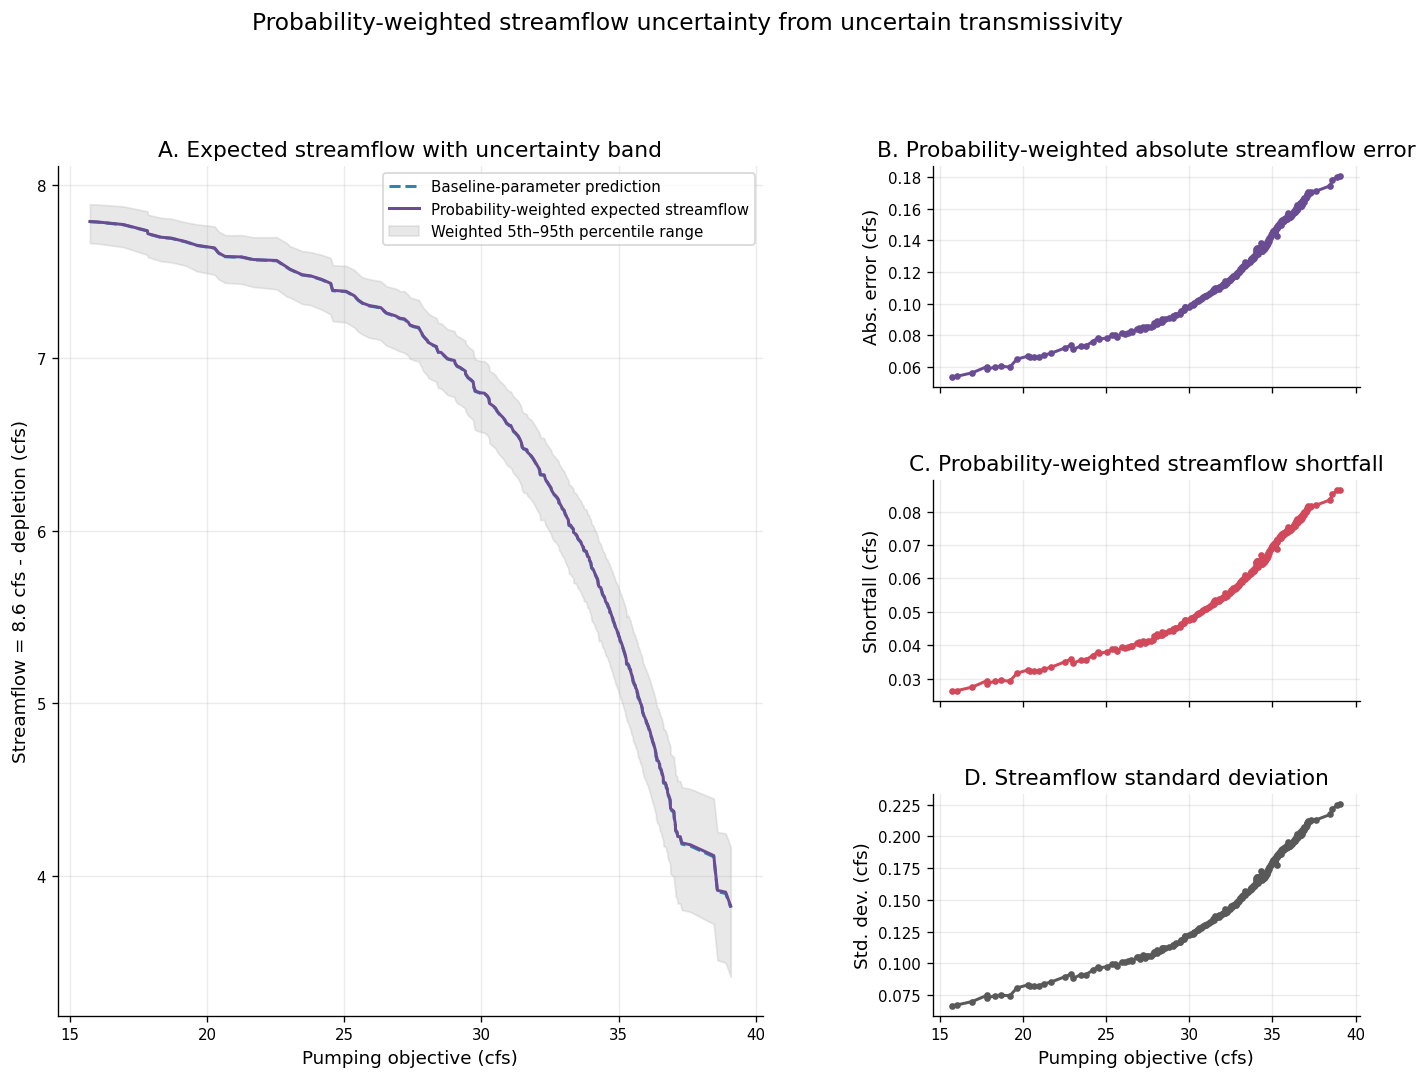

Saved figure: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302_probability_weighted_parameter_uncertainty_depletion_q/transmissivity/302_transmissivity_streamflow_uncertainty_dashboard.png
Saved probability and uncertainty figures to: /workspaces/LPR_redux/LPR_pycap_opt/notebooks/Uncertainty_Project_depletion_q/project_output/302_probability_weighted_parameter_uncertainty_depletion_q/transmissivity


In [ ]:
up.plot_parameter_probability_weights_with_curve(
    probability_table=probability_table,
    sigma_fraction=PARAMETER_SIGMA_FRACTION,
    outfile=OUTPUT_DIR / f"302_{PARAMETER_OUTPUT_TAG}_probability_weights_with_bell_curve.png",
    title="Discrete transmissivity probability weights with normal curve",
)

up.plot_parameter_probability_shaded_sigma_regions(
    sigma_fraction=PARAMETER_SIGMA_FRACTION,
    n_sigma_each_side=N_SIGMA_EACH_SIDE,
    outfile=OUTPUT_DIR / f"302_{PARAMETER_OUTPUT_TAG}_probability_shaded_sigma_regions.png",
    title="Normal probability model for transmissivity uncertainty",
)

up.plot_probability_weighted_metric(
    member_summary=member_summary,
    ycol="probability_weighted_absolute_streamflow_error_cfs",
    outfile=OUTPUT_DIR / f"302_{PARAMETER_OUTPUT_TAG}_probability_weighted_absolute_streamflow_error.png",
    title="Probability-weighted absolute streamflow error from uncertain transmissivity",
    ylabel="Absolute streamflow error (cfs)",
)

up.plot_probability_weighted_metric(
    member_summary=member_summary,
    ycol="probability_weighted_streamflow_shortfall_cfs",
    outfile=OUTPUT_DIR / f"302_{PARAMETER_OUTPUT_TAG}_probability_weighted_streamflow_shortfall.png",
    title="Probability-weighted streamflow shortfall from uncertain transmissivity",
    ylabel="Streamflow shortfall (cfs)",
)

up.plot_probability_weighted_metric(
    member_summary=member_summary,
    ycol="streamflow_std_cfs",
    outfile=OUTPUT_DIR / f"302_{PARAMETER_OUTPUT_TAG}_streamflow_standard_deviation.png",
    title="Streamflow standard deviation from uncertain transmissivity",
    ylabel="Streamflow standard deviation (cfs)",
)

up.plot_probability_weighted_streamflow_dashboard_depletion_q(
    member_summary=member_summary,
    outfile=OUTPUT_DIR / f"302_{PARAMETER_OUTPUT_TAG}_streamflow_uncertainty_dashboard.png",
    title="Probability-weighted streamflow uncertainty from uncertain transmissivity",
)

print("Saved probability and uncertainty figures to:", OUTPUT_DIR)


## 7. Interpret the probability-weighted uncertainty result

This section prints the headline metrics that are most likely to be useful for advisor discussion and the eventual report.


In [ ]:
def scalar(metric_name):
    row = overall_summary.loc[overall_summary["metric"] == metric_name, "value"]
    return np.nan if row.empty else float(row.iloc[0])

print("Mean probability-weighted absolute streamflow error (cfs):", scalar("mean_probability_weighted_absolute_streamflow_error_cfs"))
print("Max probability-weighted absolute streamflow error (cfs):", scalar("max_probability_weighted_absolute_streamflow_error_cfs"))
print("Mean probability-weighted streamflow shortfall (cfs):", scalar("mean_probability_weighted_streamflow_shortfall_cfs"))
print("Max probability-weighted streamflow shortfall (cfs):", scalar("max_probability_weighted_streamflow_shortfall_cfs"))
print("Mean streamflow standard deviation (cfs):", scalar("mean_streamflow_std_cfs"))
print("Max streamflow standard deviation (cfs):", scalar("max_streamflow_std_cfs"))
print("Interpretation: absolute error measures expected magnitude of streamflow error, while shortfall measures downside risk to streamflow.")


Mean probability-weighted absolute streamflow error (cfs): 0.12648311417186178
Max probability-weighted absolute streamflow error (cfs): 0.1808046648891381
Mean probability-weighted streamflow shortfall (cfs): 0.061057529167920045
Max probability-weighted streamflow shortfall (cfs): 0.08647106607131799
Mean streamflow standard deviation (cfs): 0.15746767393907957
Max streamflow standard deviation (cfs): 0.2252414572903994
Interpretation: absolute error measures expected magnitude of streamflow error, while shortfall measures downside risk to streamflow.


## 8. List final outputs


In [ ]:
for path in sorted(OUTPUT_DIR.glob("*")):
    print(path.name)


302_transmissivity_probability_reevaluation_long.csv
302_transmissivity_probability_shaded_sigma_regions.png
302_transmissivity_probability_weighted_absolute_streamflow_error.png
302_transmissivity_probability_weighted_member_summary.csv
302_transmissivity_probability_weighted_overall_summary.csv
302_transmissivity_probability_weighted_streamflow_shortfall.png
302_transmissivity_probability_weights.csv
302_transmissivity_probability_weights_with_bell_curve.png
302_transmissivity_streamflow_standard_deviation.png
302_transmissivity_streamflow_uncertainty_dashboard.png
